In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import cv2
import random
from pathlib import Path

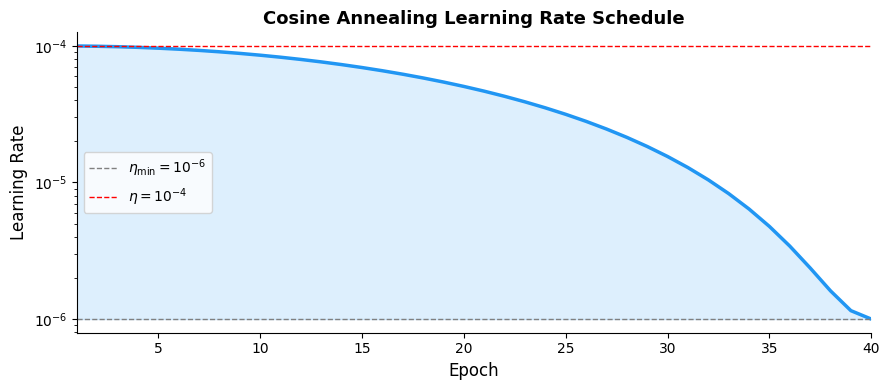

lr_schedule.png saved.


In [3]:
# ── 1. Learning Rate Schedule ─────────────────────────────────────────
T = 40
eta = 1e-4
eta_min = 1e-6
epochs = np.arange(1, T + 1)
lr = eta_min + 0.5 * (eta - eta_min) * (1 + np.cos(epochs * np.pi / T))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, lr, color='#2196F3', linewidth=2.5)
ax.fill_between(epochs, eta_min, lr, alpha=0.15, color='#2196F3')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Cosine Annealing Learning Rate Schedule',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.set_xlim(1, T)
ax.axhline(eta_min, color='gray', linestyle='--',
           linewidth=1, label=f'$\\eta_{{\\min}} = 10^{{-6}}$')
ax.axhline(eta, color='red', linestyle='--',
           linewidth=1, label=f'$\\eta = 10^{{-4}}$')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('images/lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()
print('lr_schedule.png saved.')

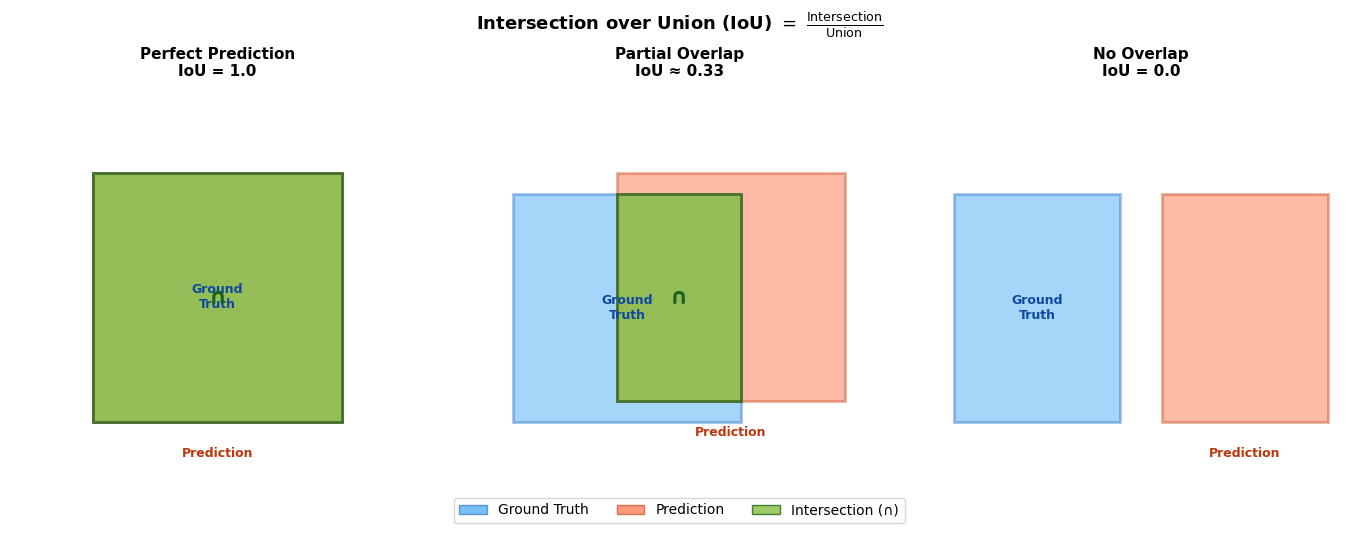

iou_diagram.png saved.


In [4]:
# ── 2. IoU Diagram ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = {
    'gt':           '#2196F3',   # blue  — ground truth only
    'pred':         '#FF5722',   # red   — prediction only
    'intersection': '#8BC34A',   # green — overlap
}


def draw_iou_panel(ax, title, gt_rect, pred_rect, show_labels=True):
    """Draw two overlapping rectangles and shade their regions."""
    from matplotlib.patches import Rectangle
    from matplotlib.patches import FancyArrowPatch

    gx, gy, gw, gh = gt_rect
    px, py, pw, ph = pred_rect

    # Intersection bounds
    ix = max(gx, px)
    iy = max(gy, py)
    ix2 = min(gx+gw, px+pw)
    iy2 = min(gy+gh, py+ph)
    has_inter = ix2 > ix and iy2 > iy

    # Ground truth (blue, semi-transparent)
    ax.add_patch(Rectangle((gx, gy), gw, gh,
                           facecolor=colors['gt'],
                           edgecolor='#1565C0',
                           alpha=0.4, linewidth=2,
                           label='Ground Truth'))
    # Prediction (red, semi-transparent)
    ax.add_patch(Rectangle((px, py), pw, ph,
                           facecolor=colors['pred'],
                           edgecolor='#BF360C',
                           alpha=0.4, linewidth=2,
                           label='Prediction'))
    # Intersection (green, opaque)
    if has_inter:
        ax.add_patch(Rectangle((ix, iy), ix2-ix, iy2-iy,
                               facecolor=colors['intersection'],
                               edgecolor='#33691E',
                               alpha=0.85, linewidth=2,
                               label='Intersection'))

    if show_labels:
        # Ground truth label
        ax.text(gx + gw/2, gy + gh/2, 'Ground\nTruth',
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='#0D47A1')
        # Prediction label
        ax.text(px + pw/2, py - 0.06, 'Prediction',
                ha='center', va='top',
                fontsize=9, fontweight='bold', color='#BF360C')
        # Intersection label
        if has_inter:
            ax.text((ix+ix2)/2, (iy+iy2)/2, '∩',
                    ha='center', va='center',
                    fontsize=16, fontweight='bold', color='#1B5E20')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)


# Panel 1: Perfect prediction (IoU = 1.0)
draw_iou_panel(axes[0],
               'Perfect Prediction\nIoU = 1.0',
               gt_rect=(0.2, 0.2, 0.6, 0.6),
               pred_rect=(0.2, 0.2, 0.6, 0.6))

# Panel 2: Partial overlap (IoU ≈ 0.33)
draw_iou_panel(axes[1],
               'Partial Overlap\nIoU ≈ 0.33',
               gt_rect=(0.1, 0.2, 0.55, 0.55),
               pred_rect=(0.35, 0.25, 0.55, 0.55))

# Panel 3: No overlap (IoU = 0.0)
draw_iou_panel(axes[2],
               'No Overlap\nIoU = 0.0',
               gt_rect=(0.05, 0.2, 0.4, 0.55),
               pred_rect=(0.55, 0.2, 0.4, 0.55),
               show_labels=True)

# Shared legend
legend_handles = [
    mpatches.Patch(facecolor=colors['gt'],
                   edgecolor='#1565C0', alpha=0.6,
                   label='Ground Truth'),
    mpatches.Patch(facecolor=colors['pred'],
                   edgecolor='#BF360C', alpha=0.6,
                   label='Prediction'),
    mpatches.Patch(facecolor=colors['intersection'],
                   edgecolor='#33691E', alpha=0.85,
                   label='Intersection (∩)'),
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02),
           frameon=True)

fig.suptitle(
    r'Intersection over Union (IoU) $=$ '
    r'$\frac{\mathrm{Intersection}}{\mathrm{Union}}$',
    fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('images/iou_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('iou_diagram.png saved.')



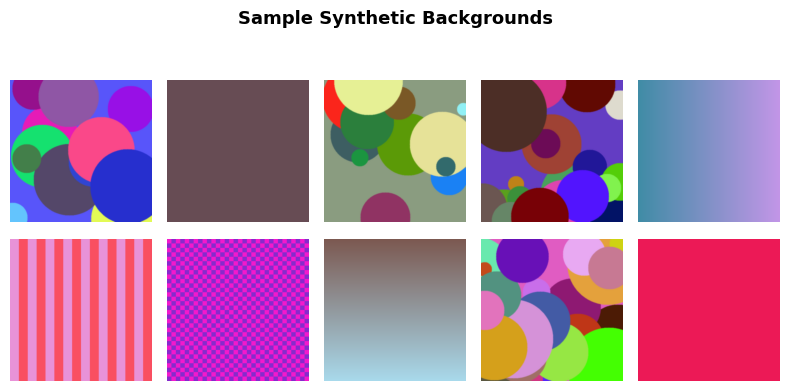

Saved.


In [36]:
bg_dir = Path('.\\outputs\\nb02\\synthetic_backgrounds')
bg_paths = sorted(bg_dir.glob('*.png'))

# random.seed(99)
samples = random.sample(bg_paths, 10)

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
axes = axes.flatten()

for ax, path in zip(axes, samples):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Sample Synthetic Backgrounds',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./images/pipe_synthetic_bg_samples.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

Selecting sample image...
  Selected: IMG_1242.jpg
  Synthetic background used: bg_0013.png


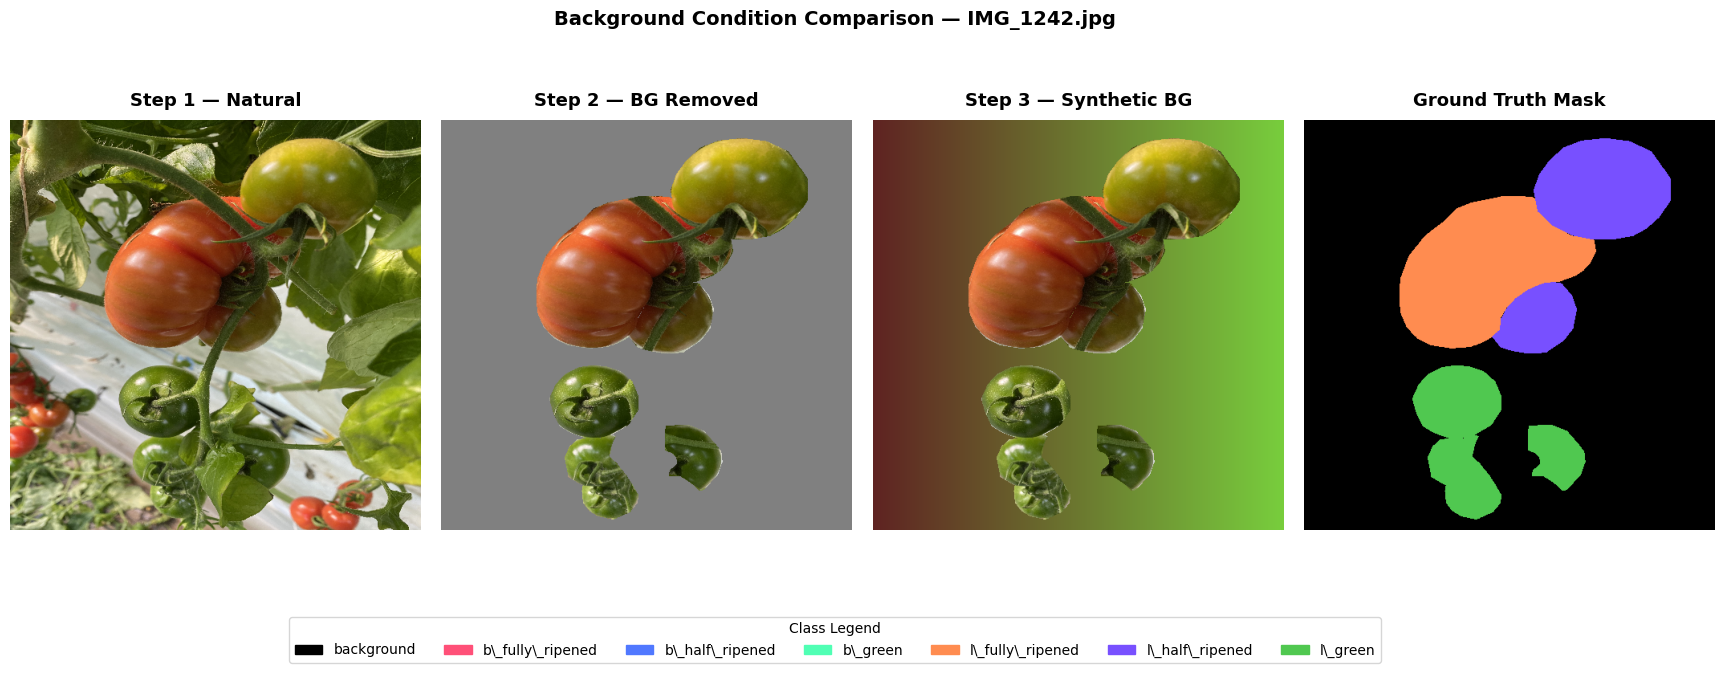


Saved → images\bg_mode_comparison.png
  Individual panel saved → images\bg_mode_individual\panel_natural.png
  Individual panel saved → images\bg_mode_individual\panel_bg_removed.png
  Individual panel saved → images\bg_mode_individual\panel_synthetic.png
  Individual panel saved → images\bg_mode_individual\panel_ground_truth.png

Done.


In [30]:
# ── STANDALONE | Background Mode Comparison for Thesis ──────────────────────
import os, json, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict

# ── Configuration — adjust these paths if needed ────────────────────────────
INPUT_DIR     = Path('C:\\Personal Data\\Thesis\\tomato-seg-latest-sep\\data\\tomato-dataset')
TRAIN_IMG_DIR = INPUT_DIR / 'Train' / 'img'
TRAIN_ANN_DIR = INPUT_DIR / 'Train' / 'ann'
OUTPUT_DIR = Path('./images/')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED              = 99
IMG_SIZE          = 512
NEUTRAL_BG_COLOR  = (128, 128, 128)

# ── Use the same synthetic backgrounds generated in NB-02 ───────────────────
BG_DIR = Path(
    'C:/Personal Data/Thesis/tomato-seg-latest/outputs/nb02/synthetic_backgrounds')

synthetic_bg_paths = list(BG_DIR.glob('*.png')) + list(BG_DIR.glob('*.jpg'))
synthetic_bg_paths = [str(p) for p in synthetic_bg_paths]

chosen_bg_path = random.choice(synthetic_bg_paths)

bg_syn_bgr = cv2.imread(chosen_bg_path)
bg_syn_rgb = cv2.cvtColor(bg_syn_bgr, cv2.COLOR_BGR2RGB)

if not synthetic_bg_paths:
    raise ValueError(f'No background images found in {BG_DIR}')

# ── Class configuration ──────────────────────────────────────────────────────
CLASS_NAMES = ['background', 'b_fully_ripened', 'b_half_ripened', 'b_green',
               'l_fully_ripened', 'l_half_ripened', 'l_green']
CLASS_TITLE_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES) if n != 'background'}
PAINT_PRIORITY = ['l_green', 'b_green', 'l_fully_ripened',
                  'b_fully_ripened', 'l_half_ripened', 'b_half_ripened']
CLASS_COLORS = [
    (  0,   0,   0),   # background
    (255,  80, 120),   # b_fully_ripened
    ( 80, 120, 255),   # b_half_ripened
    ( 80, 255, 180),   # b_green
    (255, 140,  80),   # l_fully_ripened
    (120,  80, 255),   # l_half_ripened
    ( 80, 200,  80),   # l_green
]

# ── Helper functions ─────────────────────────────────────────────────────────
def get_foreground_binary_mask(ann_path, h, w):
    with open(ann_path) as f:
        ann = json.load(f)
    fg = np.zeros((h, w), dtype=np.uint8)
    for obj in ann['objects']:
        if obj.get('classTitle', '') in CLASS_TITLE_TO_IDX:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(fg, [pts], 1)
    return fg

def generate_mask(ann_path, h, w):
    with open(ann_path) as f:
        ann = json.load(f)
    mask = np.zeros((h, w), dtype=np.uint8)
    objects_by_class = defaultdict(list)
    for obj in ann['objects']:
        ct = obj.get('classTitle', '')
        if ct in CLASS_TITLE_TO_IDX:
            objects_by_class[ct].append(obj)
    for cls_title in PAINT_PRIORITY:
        if cls_title not in objects_by_class:
            continue
        cls_idx = CLASS_TITLE_TO_IDX[cls_title]
        for obj in objects_by_class[cls_title]:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(mask, [pts], cls_idx)
    return mask

def mask_to_color(mask):
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c in range(len(CLASS_NAMES)):
        color[mask == c] = CLASS_COLORS[c]
    return color

def pick_good_sample(img_dir, ann_dir, seed=SEED, min_objects=5):
    """
    Pick one image that has at least min_objects annotated tomatoes
    and contains multiple different ripeness classes for visual variety.
    """
    rng = random.SystemRandom()
    chosen_bg_path = rng.choice(synthetic_bg_paths)
    all_imgs = sorted(list(img_dir.glob('*.jpg')))
    rng.shuffle(all_imgs)
    for img_path in all_imgs:
        ann_path = ann_dir / (img_path.name + '.json')
        if not ann_path.exists():
            continue
        with open(ann_path) as f:
            ann = json.load(f)
        classes_present = set(
            obj.get('classTitle', '')
            for obj in ann['objects']
            if obj.get('classTitle', '') in CLASS_TITLE_TO_IDX
        )
        n_objects = len([
            obj for obj in ann['objects']
            if obj.get('classTitle', '') in CLASS_TITLE_TO_IDX
        ])
        # Want multiple classes and enough objects
        if len(classes_present) >= 3 and n_objects >= min_objects:
            return img_path, ann_path
    # Fallback — return first valid pair
    for img_path in sorted(img_dir.glob('*.jpg')):
        ann_path = ann_dir / (img_path.name + '.json')
        if ann_path.exists():
            return img_path, ann_path

# ── Pick one good sample image ───────────────────────────────────────────────
print('Selecting sample image...')
img_path, ann_path = pick_good_sample(TRAIN_IMG_DIR, TRAIN_ANN_DIR)
print(f'  Selected: {img_path.name}')

# ── Load and resize ──────────────────────────────────────────────────────────
img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h_orig, w_orig = img_rgb.shape[:2]

img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
h, w = img_resized.shape[:2]

# ── Ground truth mask ────────────────────────────────────────────────────────
mask = generate_mask(ann_path, h_orig, w_orig)
mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                           interpolation=cv2.INTER_NEAREST)
mask_colored = mask_to_color(mask_resized)

# ── Foreground binary mask ───────────────────────────────────────────────────
fg = get_foreground_binary_mask(ann_path, h_orig, w_orig)
fg_resized = cv2.resize(fg, (IMG_SIZE, IMG_SIZE),
                         interpolation=cv2.INTER_NEAREST)
fg3 = np.stack([fg_resized] * 3, axis=-1)

# ── Version 1: Natural ───────────────────────────────────────────────────────
natural = img_resized.copy()

# ── Version 2: Background Removed (neutral gray) ────────────────────────────
bg_gray = np.full((IMG_SIZE, IMG_SIZE, 3), NEUTRAL_BG_COLOR, dtype=np.uint8)
removed = np.where(fg3 == 1, img_resized, bg_gray)

# ── Version 3: Synthetic background ─────────────────────────────────────────
# Pick a visually interesting synthetic bg — use index 56 which is a
# gradient type, or let the seed choose
rng = random.Random(SEED + 99)
chosen_bg_path = rng.choice(synthetic_bg_paths)
bg_syn_bgr = cv2.imread(chosen_bg_path)
bg_syn_rgb  = cv2.cvtColor(bg_syn_bgr, cv2.COLOR_BGR2RGB)
bg_syn_rgb  = cv2.resize(bg_syn_rgb, (IMG_SIZE, IMG_SIZE))
synthetic   = np.where(fg3 == 1, img_resized, bg_syn_rgb)

print(f'  Synthetic background used: {Path(chosen_bg_path).name}')

# ── Create the thesis figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 4,
    figsize=(22, 6),
    gridspec_kw={'wspace': 0.05}
)

titles = [
    'Step 1 — Natural',
    'Step 2 — BG Removed',
    'Step 3 — Synthetic BG',
    'Ground Truth Mask'
]
images = [natural, removed, synthetic, mask_colored]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')
    # Add thin border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor('#cccccc')

# ── Legend for mask colors ────────────────────────────────────────────────────
patches = [
    mpatches.Patch(
        color=np.array(CLASS_COLORS[i]) / 255.,
        label=CLASS_NAMES[i].replace('_', '\\_')
    )
    for i in range(len(CLASS_NAMES))
]
fig.legend(
    handles=patches,
    loc='lower center',
    ncol=7,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
    title='Class Legend',
    title_fontsize=10
)

plt.suptitle(
    f'Background Condition Comparison — {img_path.name}',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

# ── Save high-resolution version for thesis ──────────────────────────────────
save_path = OUTPUT_DIR / 'bg_mode_comparison.png'
plt.savefig(
    save_path,
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print(f'\nSaved → {save_path}')

# ── Also save each panel individually in case you need them separately ───────
individual_dir = OUTPUT_DIR / 'bg_mode_individual'
individual_dir.mkdir(exist_ok=True)

for img_arr, fname in [
    (natural,      'panel_natural.png'),
    (removed,      'panel_bg_removed.png'),
    (synthetic,    'panel_synthetic.png'),
    (mask_colored, 'panel_ground_truth.png'),
]:
    out = cv2.cvtColor(img_arr, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(individual_dir / fname), out)
    print(f'  Individual panel saved → {individual_dir / fname}')

print('\nDone.')

Device  : cpu
Save to : images

Loading dataset splits...
  Test pairs loaded: 103
  Synthetic backgrounds found: 200

Loading model checkpoints...
  Loaded: step1_mobilenetv2_natural_best.pth
  Loaded: step1_efficientnetb0_natural_best.pth
  Loaded: step2_mobilenetv2_removed_best.pth

Generating Step 1 confusion matrices...


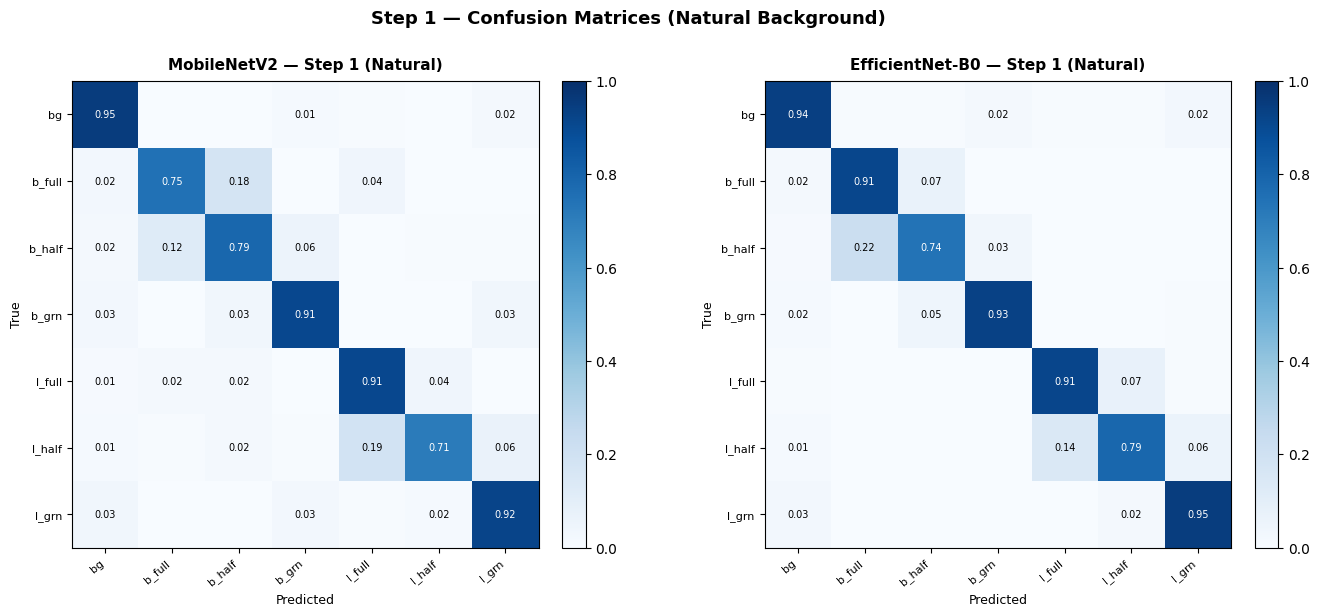

  Saved → images\step1_confusion.png

Generating Step 1 prediction visualizations...


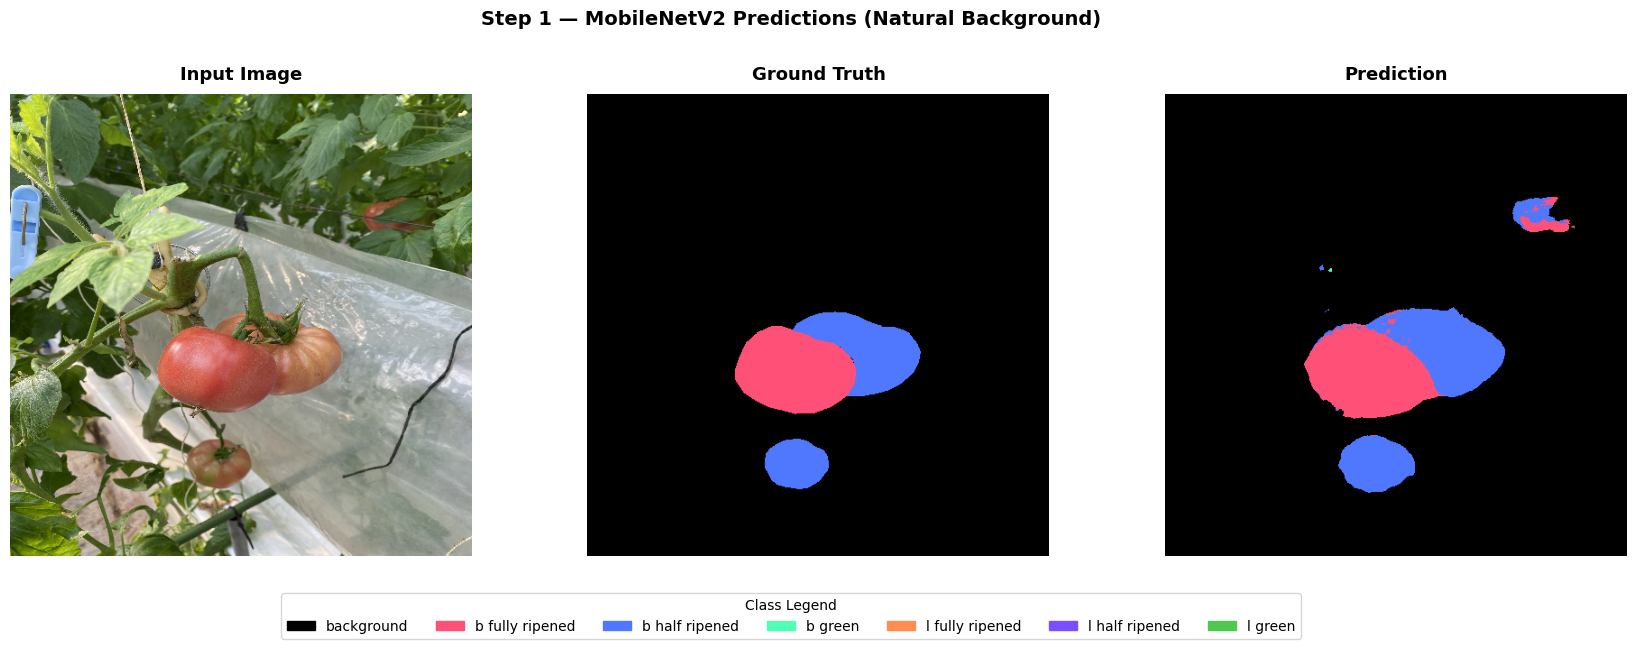

  Saved → images\step1_mobilenetv2_predictions.png

Generating Step 1 Grad-CAM visualizations...


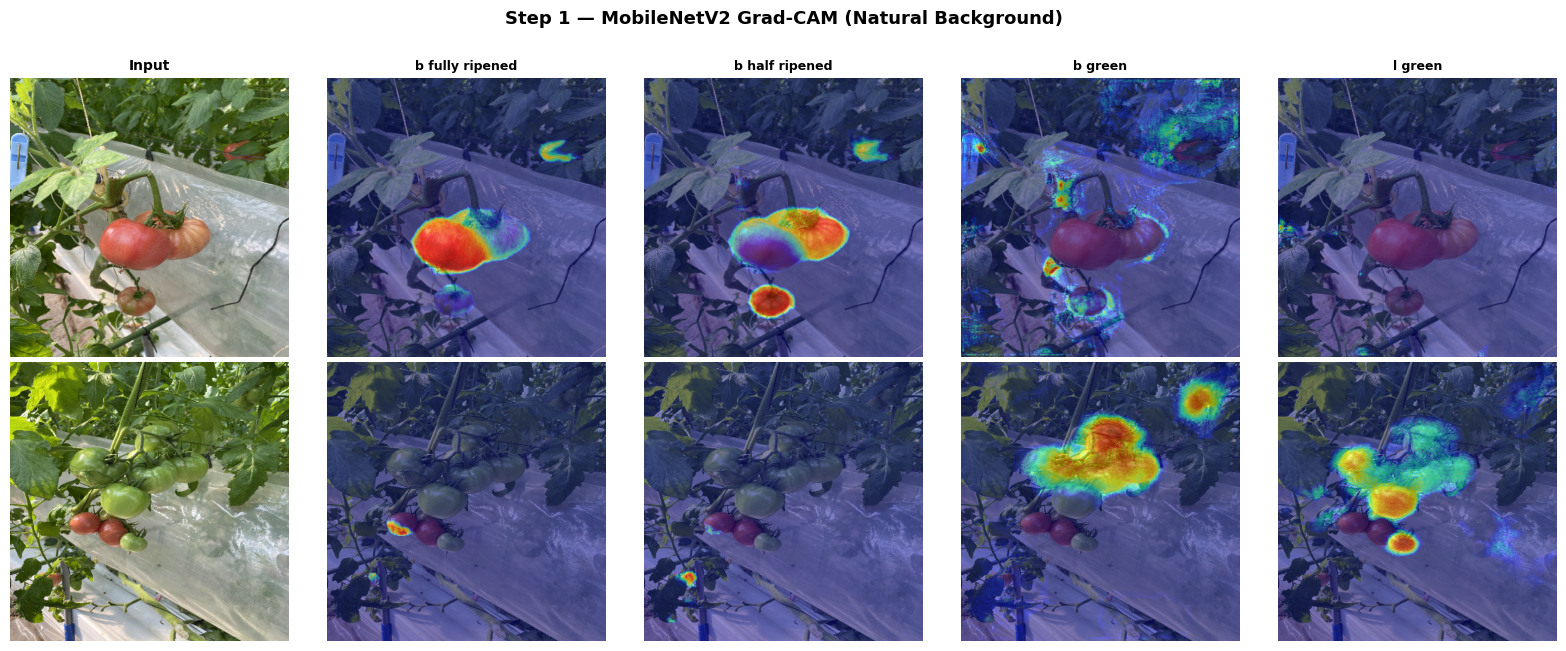

  Saved → images\step1_mobilenetv2_gradcam.png

Generating Step 2 prediction visualizations...


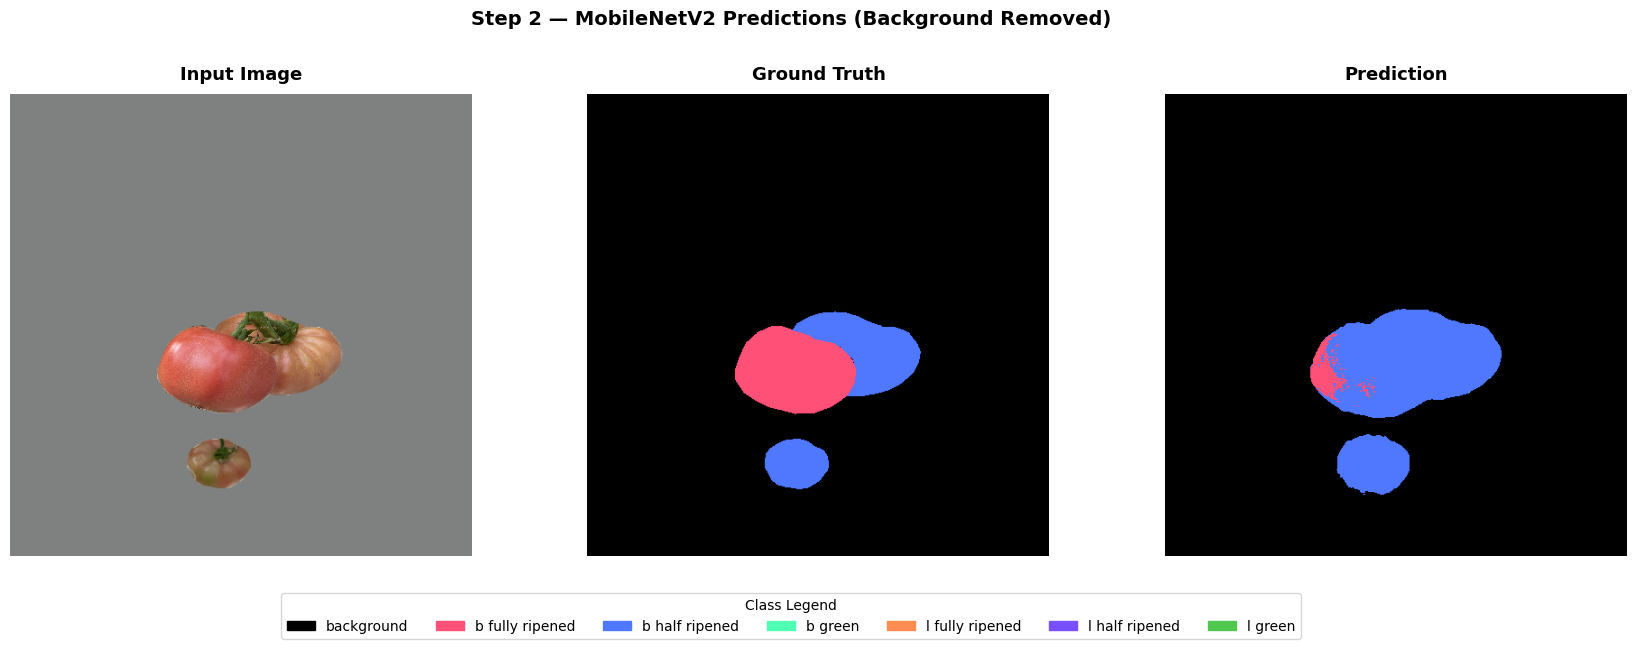

  Saved → images\step2_mobilenetv2_predictions.png

Generating Step 3 prediction visualizations...
  Loaded: step3_mobilenetv2_synthetic_best.pth


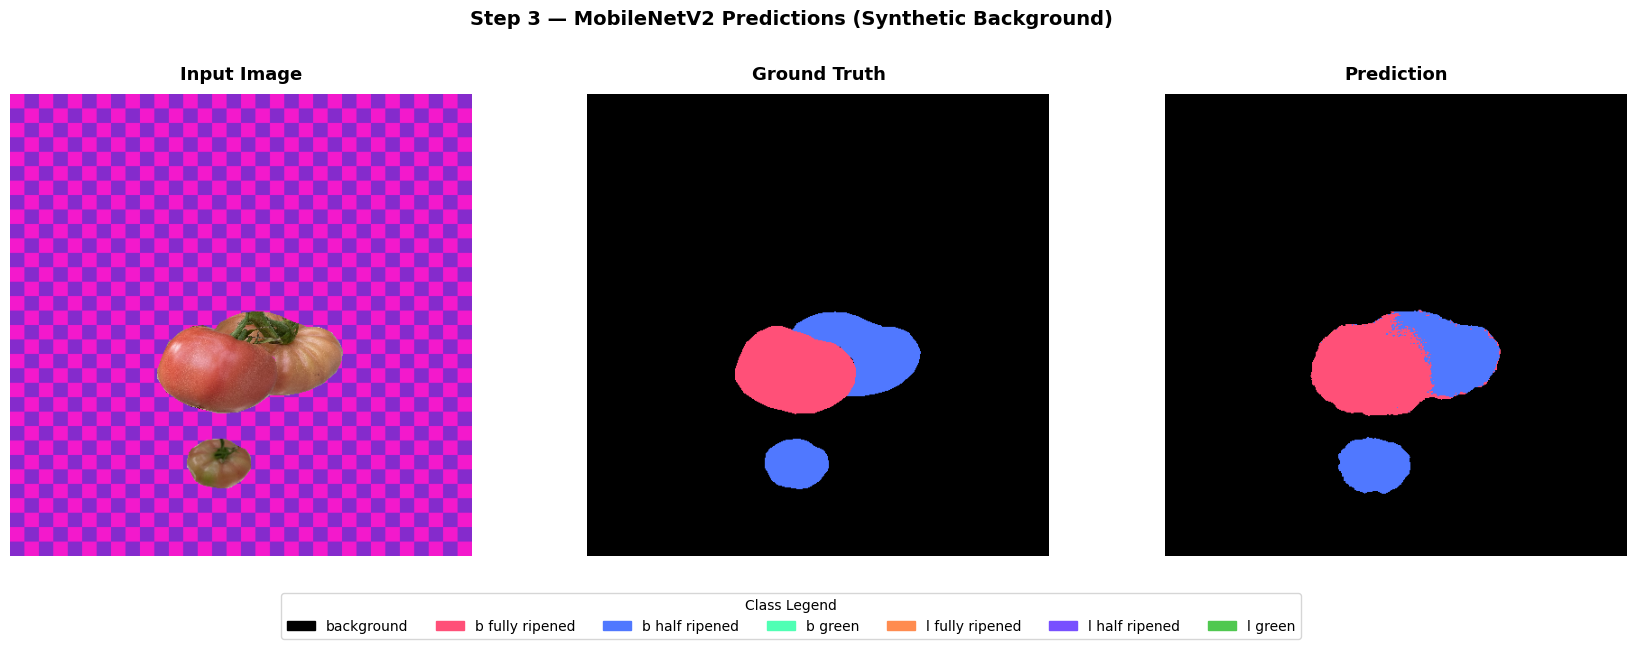

  Saved → images\step3_mobilenetv2_predictions.png

  ALL FIGURES GENERATED SUCCESSFULLY

Output directory: images

Files saved:
  bg_mode_comparison.png                          1306.3 KB
  iou_diagram.png                                   43.0 KB
  lr_schedule.png                                   44.2 KB
  pipe_synthetic_bg_samples.png                     87.1 KB
  step1_confusion.png                              158.8 KB
  step1_mobilenetv2_gradcam.png                   6281.6 KB
  step1_mobilenetv2_predictions.png               2007.5 KB
  step2_mobilenetv2_predictions.png                302.0 KB
  step3_mobilenetv2_predictions.png                370.1 KB


In [41]:
# ── STANDALONE | Generate All Missing Thesis Figures ────────────────────────
# Requires: saved model checkpoints from NB-04
# Generates: step1_confusion, step1_predictions, step1_gradcam, step2_predictions
# Run this AFTER your main pipeline has completed on Kaggle
# Or run locally if you have the checkpoints downloaded

import os
import json
import random
import copy
import warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 — CONFIGURATION
# Change these paths to match your local setup or Kaggle paths
# ─────────────────────────────────────────────────────────────────────────────

# ── Set IS_LOCAL = True if running on your PC, False if on Kaggle ────────────
IS_LOCAL = True

if IS_LOCAL:
    INPUT_DIR = Path(
        'C:/Personal Data/Thesis/tomato-seg-latest-sep/data/tomato-dataset')
    OUTPUTS_DIR_FOR_SPLIT_FILE = Path(
        'C:/Personal Data/Thesis/tomato-seg-latest/outputs/')
    MODELS_DIR = OUTPUTS_DIR_FOR_SPLIT_FILE / 'models'
    SPLIT_FILE = OUTPUTS_DIR_FOR_SPLIT_FILE / 'nb01' / 'dataset_splits.json'
    BG_DIR = OUTPUTS_DIR_FOR_SPLIT_FILE / 'nb02' / 'synthetic_backgrounds'
    SAVE_DIR = Path('./images')
else:
    INPUT_DIR = Path(
        '/kaggle/input/datasets/sharifbek/laboro-tomato/tomato-dataset')
    OUTPUTS_DIR = Path('/kaggle/working/outputs')
    MODELS_DIR = OUTPUTS_DIR / 'models'
    SPLIT_FILE = OUTPUTS_DIR / 'nb01' / 'dataset_splits.json'
    BG_DIR = OUTPUTS_DIR / 'nb02' / 'synthetic_backgrounds'
    SAVE_DIR = Path('/kaggle/working/outputs/thesis_figures')

TRAIN_IMG_DIR = INPUT_DIR / 'Train' / 'img'
TRAIN_ANN_DIR = INPUT_DIR / 'Train' / 'ann'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
IMG_SIZE = 512
NUM_CLASSES = 7
NEUTRAL_BG_COLOR = (128, 128, 128)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device  : {DEVICE}')
print(f'Save to : {SAVE_DIR}')

# ── Class configuration ───────────────────────────────────────────────────────
CLASS_NAMES = [
    'background', 'b_fully_ripened', 'b_half_ripened', 'b_green',
    'l_fully_ripened', 'l_half_ripened', 'l_green'
]
CLASS_TITLE_TO_IDX = {n: i for i, n in enumerate(
    CLASS_NAMES) if n != 'background'}
PAINT_PRIORITY = [
    'l_green', 'b_green', 'l_fully_ripened',
    'b_fully_ripened', 'l_half_ripened', 'b_half_ripened'
]
CLASS_COLORS = [
    (0,   0,   0),
    (255,  80, 120),
    (80, 120, 255),
    (80, 255, 180),
    (255, 140,  80),
    (120,  80, 255),
    (80, 200,  80),
]
DENORM_MEAN = np.array([0.485, 0.456, 0.406])
DENORM_STD = np.array([0.229, 0.224, 0.225])

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────


def get_foreground_binary_mask(ann_path, h, w):
    with open(ann_path) as f:
        ann = json.load(f)
    fg = np.zeros((h, w), dtype=np.uint8)
    for obj in ann['objects']:
        if obj.get('classTitle', '') in CLASS_TITLE_TO_IDX:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(fg, [pts], 1)
    return fg


def generate_mask(ann_path, h, w):
    with open(ann_path) as f:
        ann = json.load(f)
    mask = np.zeros((h, w), dtype=np.uint8)
    objects_by_class = defaultdict(list)
    for obj in ann['objects']:
        ct = obj.get('classTitle', '')
        if ct in CLASS_TITLE_TO_IDX:
            objects_by_class[ct].append(obj)
    for cls_title in PAINT_PRIORITY:
        if cls_title not in objects_by_class:
            continue
        cls_idx = CLASS_TITLE_TO_IDX[cls_title]
        for obj in objects_by_class[cls_title]:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(mask, [pts], cls_idx)
    return mask


def mask_to_color(mask):
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        color[mask == c] = CLASS_COLORS[c]
    return color


def denorm(tensor):
    img = tensor.numpy().transpose(1, 2, 0)
    img = img * DENORM_STD + DENORM_MEAN
    return np.clip(img, 0, 1)


def get_legend_patches():
    return [
        mpatches.Patch(
            color=np.array(CLASS_COLORS[i]) / 255.,
            label=CLASS_NAMES[i].replace('_', ' ')
        )
        for i in range(NUM_CLASSES)
    ]

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — DATASET & DATALOADER
# ─────────────────────────────────────────────────────────────────────────────


def get_val_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


class TomatoDataset(Dataset):
    def __init__(self, pairs, transform=None, bg_mode='natural',
                 bg_images=None, fixed_bg=None):
        self.pairs = pairs
        self.transform = transform
        self.bg_mode = bg_mode
        self.bg_images = bg_images or []
        self.fixed_bg = fixed_bg

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, ann_p = self.pairs[idx]
        img = cv2.imread(str(img_p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        mask = generate_mask(ann_p, h, w)

        if self.bg_mode == 'removed':
            fg = get_foreground_binary_mask(ann_p, h, w)
            bg = np.full_like(img, NEUTRAL_BG_COLOR)
            fg3 = np.stack([fg] * 3, axis=-1)
            img = np.where(fg3 == 1, img, bg)

        elif self.bg_mode == 'synthetic' and self.bg_images:
            fg = get_foreground_binary_mask(ann_p, h, w)
            bg_path = self.fixed_bg[idx] if self.fixed_bg else \
                random.choice(self.bg_images)
            bg_img = cv2.imread(str(bg_path))
            if bg_img is not None:
                bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)
                bg_img = cv2.resize(bg_img, (w, h))
            else:
                bg_img = np.full_like(img, NEUTRAL_BG_COLOR)
            fg3 = np.stack([fg] * 3, axis=-1)
            img = np.where(fg3 == 1, img, bg_img)

        if self.transform:
            out = self.transform(image=img, mask=mask)
            img = out['image']
            mask = out['mask']
        return img, mask.long()

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — LOAD SPLITS AND BUILD TEST PAIRS
# ─────────────────────────────────────────────────────────────────────────────


print('\nLoading dataset splits...')
with open(SPLIT_FILE) as f:
    split_data = json.load(f)


def reconstruct_pairs(split_list):
    pairs = []
    for img_rel, ann_rel in split_list:
        img_p = INPUT_DIR / img_rel
        ann_p = INPUT_DIR / ann_rel
        if img_p.exists() and ann_p.exists():
            pairs.append((img_p, ann_p))
    return pairs


test_pairs = reconstruct_pairs(split_data['test'])
print(f'  Test pairs loaded: {len(test_pairs)}')

# Load synthetic backgrounds
bg_paths = [str(p) for p in sorted(BG_DIR.glob('*.png'))]
print(f'  Synthetic backgrounds found: {len(bg_paths)}')

# Fixed bg assignments for test set — use same seeds as main pipeline
rng_test = random.Random(SEED + 2000)
test_bg_fixed = [rng_test.choice(bg_paths) for _ in range(len(test_pairs))]

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — LOAD MODELS
# ─────────────────────────────────────────────────────────────────────────────

print('\nLoading model checkpoints...')


def load_model(encoder_name, checkpoint_path):
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=None,      # weights loaded from checkpoint
        in_channels=3,
        classes=NUM_CLASSES,
        activation=None
    ).to(DEVICE)
    state = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    print(f'  Loaded: {Path(checkpoint_path).name}')
    return model


model_m_nat = load_model(
    'mobilenet_v2',
    MODELS_DIR / 'step1_mobilenetv2_natural_best.pth'
)
model_e_nat = load_model(
    'efficientnet-b0',
    MODELS_DIR / 'step1_efficientnetb0_natural_best.pth'
)
model_m_rem = load_model(
    'mobilenet_v2',
    MODELS_DIR / 'step2_mobilenetv2_removed_best.pth'
)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — SELECT REPRESENTATIVE TEST IMAGES
# ─────────────────────────────────────────────────────────────────────────────

N_SAMPLES = 8
step = max(1, len(test_pairs) // N_SAMPLES)
vis_indices = list(range(0, len(test_pairs), step))[:N_SAMPLES]

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — FIGURE 1: STEP 1 CONFUSION MATRICES
# ─────────────────────────────────────────────────────────────────────────────

print('\nGenerating Step 1 confusion matrices...')

transform = get_val_transform()
test_ds_nat = TomatoDataset(test_pairs, transform=transform, bg_mode='natural')
test_loader_nat = DataLoader(test_ds_nat, batch_size=4,
                             shuffle=False, num_workers=0)


def collect_predictions(model, loader, device=DEVICE):
    all_pred, all_gt = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            for b in range(preds.shape[0]):
                all_pred.append(preds[b].flatten())
                all_gt.append(masks[b].numpy().flatten())
    return np.concatenate(all_pred), np.concatenate(all_gt)


pred_m, gt_m = collect_predictions(model_m_nat, test_loader_nat)
pred_e, gt_e = collect_predictions(model_e_nat, test_loader_nat)


def plot_confusion_matrix(pred, gt, title, ax):
    cm = sk_confusion_matrix(gt, pred, labels=list(range(NUM_CLASSES)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues',
                   vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    short_names = ['bg', 'b_full', 'b_half', 'b_grn',
                   'l_full', 'l_half', 'l_grn']
    ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7,
                        color='white' if v > 0.5 else 'black')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_confusion_matrix(pred_m, gt_m,
                      'MobileNetV2 — Step 1 (Natural)', axes[0])
plot_confusion_matrix(pred_e, gt_e,
                      'EfficientNet-B0 — Step 1 (Natural)', axes[1])
plt.suptitle('Step 1 — Confusion Matrices (Natural Background)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = SAVE_DIR / 'step1_confusion.png'
plt.savefig(save_path, dpi=250, bbox_inches='tight', facecolor='white')
plt.show()
print(f'  Saved → {save_path}')

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — FIGURE 2: STEP 1 PREDICTION VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────

print('\nGenerating Step 1 prediction visualizations...')


def visualize_predictions(model, dataset, indices, title, save_path):
    """
    Displays predictions in a single row per sample.
    Each sample occupies one row: Input | Ground Truth | Prediction
    Layout matches the bg_mode_comparison figure style.
    """
    model.eval()
    n = len(indices)

    # One row per sample, 3 columns each
    # figsize matches the bg_mode_comparison proportions
    fig, axes = plt.subplots(
        n, 3,
        figsize=(22, 6 * n),
        gridspec_kw={'wspace': 0.05, 'hspace': 0.08}
    )
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Input Image', 'Ground Truth', 'Prediction']

    for row, idx in enumerate(indices):
        img_t, mask_t = dataset[idx]
        img_np = denorm(img_t)

        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(DEVICE))
            pred_mask = pred.argmax(dim=1).squeeze(0).cpu().numpy()

        gt_mask = mask_t.numpy()
        gt_color = mask_to_color(gt_mask)
        pr_color = mask_to_color(pred_mask)

        for col, (im, lbl) in enumerate([
            (img_np,   col_titles[0]),
            (gt_color, col_titles[1]),
            (pr_color, col_titles[2]),
        ]):
            axes[row, col].imshow(im)

            # Column headers only on first row
            if row == 0:
                axes[row, col].set_title(
                    lbl,
                    fontsize=13,
                    fontweight='bold',
                    pad=10
                )

            axes[row, col].axis('off')

            # Same thin border style as bg_mode_comparison
            for spine in axes[row, col].spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)
                spine.set_edgecolor('#cccccc')

    # Legend below — same style as bg_mode_comparison
    patches = [
        mpatches.Patch(
            color=np.array(CLASS_COLORS[i]) / 255.,
            label=CLASS_NAMES[i].replace('_', ' ')
        )
        for i in range(NUM_CLASSES)
    ]
    fig.legend(
        handles=patches,
        loc='lower center',
        ncol=7,
        fontsize=10,
        frameon=True,
        bbox_to_anchor=(0.5, -0.04),
        title='Class Legend',
        title_fontsize=10
    )

    plt.suptitle(
        title,
        fontsize=14,
        fontweight='bold',
        y=1.02
    )

    plt.savefig(
        save_path,
        dpi=250,
        bbox_inches='tight',
        facecolor='white'
    )
    plt.show()
    print(f'  Saved → {save_path}')


visualize_predictions(
    model_m_nat,
    test_ds_nat,
    vis_indices[:1],
    'Step 1 — MobileNetV2 Predictions (Natural Background)',
    SAVE_DIR / 'step1_mobilenetv2_predictions.png'
)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — FIGURE 3: STEP 1 GRAD-CAM
# ─────────────────────────────────────────────────────────────────────────────

print('\nGenerating Step 1 Grad-CAM visualizations...')

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

    class SegTarget:
        def __init__(self, cls):
            self.cls = cls

        def __call__(self, output):
            return output[self.cls].sum()

    def generate_gradcam_figure(model, dataset, indices,
                                target_classes, target_layer,
                                title, save_path):
        model.eval()
        n_imgs = len(indices)
        n_cls = len(target_classes)

        # cols: 1 input + n_cls grad-cam maps
        fig, axes = plt.subplots(
            n_imgs, n_cls + 1,
            figsize=(3.2 * (n_cls + 1), 3.2 * n_imgs)
        )
        if n_imgs == 1:
            axes = axes[np.newaxis, :]

        for row, idx in enumerate(indices):
            img_t, _ = dataset[idx]
            img_np = denorm(img_t).astype(np.float32)

            axes[row, 0].imshow(img_np)
            axes[row, 0].set_title('Input' if row == 0 else '',
                                   fontsize=10, fontweight='bold')
            axes[row, 0].axis('off')

            for col, cls_idx in enumerate(target_classes):
                targets = [SegTarget(cls_idx)]
                with GradCAM(model=model,
                             target_layers=[target_layer]) as cam:
                    gc = cam(
                        input_tensor=img_t.unsqueeze(0).to(DEVICE),
                        targets=targets
                    )[0]
                cam_img = show_cam_on_image(img_np, gc, use_rgb=True)
                axes[row, col + 1].imshow(cam_img)
                if row == 0:
                    label = CLASS_NAMES[cls_idx].replace('_', ' ')
                    axes[row, col + 1].set_title(
                        label, fontsize=9, fontweight='bold'
                    )
                axes[row, col + 1].axis('off')

        plt.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig(save_path, dpi=250, bbox_inches='tight',
                    facecolor='white')
        plt.show()
        print(f'  Saved → {save_path}')

    # Target layer — last conv before segmentation head
    target_layer_m = model_m_nat.segmentation_head[0]

    # Use 4 images and all 6 tomato classes (skip background=0)
    gradcam_indices = vis_indices[:2]
    gradcam_classes = [1, 2, 3, 6]
    # 1=b_fully_ripened  2=b_half_ripened
    # 3=b_green          6=l_green
    # This gives 4 columns + 1 input = 5 columns total
    # Wide but fits on a landscape thesis page

    generate_gradcam_figure(
        model_m_nat,
        test_ds_nat,
        gradcam_indices,
        gradcam_classes,
        target_layer_m,
        'Step 1 — MobileNetV2 Grad-CAM (Natural Background)',
        SAVE_DIR / 'step1_mobilenetv2_gradcam.png'
    )

except ImportError:
    print('  pytorch_grad_cam not installed.')
    print('  Install with: pip install grad-cam')
    print('  Skipping Grad-CAM figure.')

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — FIGURE 4: STEP 2 PREDICTION VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────

print('\nGenerating Step 2 prediction visualizations...')

test_ds_rem = TomatoDataset(
    test_pairs,
    transform=get_val_transform(),
    bg_mode='removed'
)

visualize_predictions(
    model_m_rem,
    test_ds_rem,
    vis_indices[:1],
    'Step 2 — MobileNetV2 Predictions (Background Removed)',
    SAVE_DIR / 'step2_mobilenetv2_predictions.png'
)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9B — FIGURE 5: STEP 3 PREDICTION VISUALIZATIONS (SYNTHETIC)
# ─────────────────────────────────────────────────────────────────────────────

print('\nGenerating Step 3 prediction visualizations...')

# Load Step 3 model
model_m_syn = load_model(
    'mobilenet_v2',
    MODELS_DIR / 'step3_mobilenetv2_synthetic_best.pth'
)

# Build synthetic test dataset with fixed backgrounds
# using the same seed as the main pipeline
test_ds_syn = TomatoDataset(
    test_pairs,
    transform=get_val_transform(),
    bg_mode='synthetic',
    bg_images=bg_paths,
    fixed_bg=test_bg_fixed
)

visualize_predictions(
    model_m_syn,
    test_ds_syn,
    vis_indices[:1],
    'Step 3 — MobileNetV2 Predictions (Synthetic Background)',
    SAVE_DIR / 'step3_mobilenetv2_predictions.png'
)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 — DONE
# ─────────────────────────────────────────────────────────────────────────────

print('\n' + '='*60)
print('  ALL FIGURES GENERATED SUCCESSFULLY')
print('='*60)
print(f'\nOutput directory: {SAVE_DIR}')
print('\nFiles saved:')
for f in sorted(SAVE_DIR.glob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size_kb:>8.1f} KB')

In [1]:
# gradcam_local.py
# Run: python gradcam_local.py

import os
import json
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── 1. PATHS — edit these to match your local setup ──────────────────────────
# your local dataset folder
DATASET_DIR = Path(
    'C:/Personal Data/Thesis/tomato-seg-latest-sep/data/tomato-dataset')
MODELS_DIR = Path('C:/Personal Data/Thesis/tomato-seg-latest/outputs/models')          # where your .pth files live
SPLIT_FILE = Path('C:/Personal Data/Thesis/tomato-seg-latest/outputs/nb01/dataset_splits.json')  # dataset splits from NB-01
SYNTH_BG_DIR = Path('C:/Personal Data/Thesis/tomato-seg-latest/outputs/nb02/synthetic_backgrounds')  # synthetic backgrounds from NB-02
OUTPUT_DIR = Path('./images/gradcam_examples') 
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── 2. CONFIG ─────────────────────────────────────────────────────────────────
SEED = 42
IMG_SIZE = 512
NUM_CLASSES = 7
BATCH_SIZE = 4
NUM_WORKERS = 0   

CLASS_NAMES = ['background', 'b_fully_ripened', 'b_half_ripened', 'b_green',
               'l_fully_ripened', 'l_half_ripened', 'l_green']

CLASS_COLORS = [
    (0,   0,   0),
    (255,  80, 120),
    (80, 120, 255),
    (80, 255, 180),
    (255, 140,  80),
    (120,  80, 255),
    (80, 200,  80),
]

CLASS_TITLE_TO_IDX = {n: i for i, n in enumerate(
    CLASS_NAMES) if n != 'background'}

PAINT_PRIORITY = ['l_green', 'b_green', 'l_fully_ripened',
                  'b_fully_ripened', 'l_half_ripened', 'b_half_ripened']

NEUTRAL_BG_COLOR = (128, 128, 128)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── 3. MASK GENERATION ────────────────────────────────────────────────────────


def generate_mask_from_annotation(ann_path, img_height=None, img_width=None):
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    h = img_height or ann['size']['height']
    w = img_width or ann['size']['width']
    mask = np.zeros((h, w), dtype=np.uint8)
    objects_by_class = defaultdict(list)
    for obj in ann['objects']:
        ct = obj.get('classTitle', '')
        if ct in CLASS_TITLE_TO_IDX:
            objects_by_class[ct].append(obj)
    for cls_title in PAINT_PRIORITY:
        if cls_title not in objects_by_class:
            continue
        cls_idx = CLASS_TITLE_TO_IDX[cls_title]
        for obj in objects_by_class[cls_title]:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(mask, [pts], cls_idx)
    return mask


def get_foreground_binary_mask(ann_path, img_height=None, img_width=None):
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    h = img_height or ann['size']['height']
    w = img_width or ann['size']['width']
    fg = np.zeros((h, w), dtype=np.uint8)
    for obj in ann['objects']:
        if obj.get('classTitle', '') in CLASS_TITLE_TO_IDX:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(fg, [pts], 1)
    return fg

# ── 4. DATASET ────────────────────────────────────────────────────────────────


def get_val_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


class TomatoSegDataset(Dataset):
    def __init__(self, pairs, transform=None, bg_mode='natural',
                 bg_images=None, fixed_bg_assignment=None):
        self.pairs = pairs
        self.transform = transform
        self.bg_mode = bg_mode
        self.bg_images = bg_images or []
        self.fixed_bg_assignment = fixed_bg_assignment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, ann_p = self.pairs[idx]
        img = cv2.imread(str(img_p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        mask = generate_mask_from_annotation(ann_p, h, w)

        if self.bg_mode == 'removed':
            fg = get_foreground_binary_mask(ann_p, h, w)
            bg = np.full_like(img, NEUTRAL_BG_COLOR, dtype=np.uint8)
            fg3 = np.stack([fg] * 3, axis=-1)
            img = np.where(fg3 == 1, img, bg)

        elif self.bg_mode == 'synthetic' and len(self.bg_images) > 0:
            fg = get_foreground_binary_mask(ann_p, h, w)
            if self.fixed_bg_assignment is not None:
                bg_path = self.fixed_bg_assignment[idx]
            else:
                bg_path = random.choice(self.bg_images)
            bg_img = cv2.imread(str(bg_path))
            if bg_img is not None:
                bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)
                bg_img = cv2.resize(bg_img, (w, h))
            else:
                bg_img = np.full_like(img, NEUTRAL_BG_COLOR, dtype=np.uint8)
            fg3 = np.stack([fg] * 3, axis=-1)
            img = np.where(fg3 == 1, img, bg_img)

        if self.transform:
            out = self.transform(image=img, mask=mask)
            img = out['image']
            mask = out['mask']
        return img, mask.long()

# ── 5. LOAD SPLITS ────────────────────────────────────────────────────────────


def load_splits(split_file, dataset_dir):
    with open(split_file) as f:
        data = json.load(f)

    def to_pairs(lst):
        return [(Path(dataset_dir) / img, Path(dataset_dir) / ann)
                for img, ann in lst]
    return to_pairs(data['test'])   # only test split needed for Grad-CAM


print('Loading test split...')
test_pairs = load_splits(SPLIT_FILE, DATASET_DIR)
print(f'Test samples: {len(test_pairs)}')

# ── 6. LOAD SYNTHETIC BG PATHS ────────────────────────────────────────────────
synthetic_bg_paths = sorted([str(p) for p in SYNTH_BG_DIR.glob('bg_*.png')])
print(f'Synthetic backgrounds found: {len(synthetic_bg_paths)}')

rng_test = random.Random(SEED + 2000)
test_bg_assignment = [rng_test.choice(synthetic_bg_paths)
                      for _ in range(len(test_pairs))]

# ── 7. BUILD TEST DATASETS ────────────────────────────────────────────────────
tfm = get_val_transform()

test_ds_natural = TomatoSegDataset(
    test_pairs, transform=tfm, bg_mode='natural')
test_ds_removed = TomatoSegDataset(
    test_pairs, transform=tfm, bg_mode='removed')
test_ds_synth = TomatoSegDataset(test_pairs, transform=tfm, bg_mode='synthetic',
                                 bg_images=synthetic_bg_paths,
                                 fixed_bg_assignment=test_bg_assignment)

print(f'Datasets ready: {len(test_ds_natural)} samples each')

# ── 8. MODEL FACTORY & LOADER ─────────────────────────────────────────────────


def create_unet_model(encoder_name):
    model = smp.Unet(encoder_name=encoder_name, encoder_weights=None,
                     in_channels=3, classes=NUM_CLASSES, activation=None)
    return model.to(DEVICE)


def load_model(encoder_name, ckpt_path):
    model = create_unet_model(encoder_name)
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    print(f'  Loaded: {Path(ckpt_path).name}')
    return model


print('\nLoading all 6 checkpoints...')
models = {
    'mobilenet_natural': load_model('mobilenet_v2',    MODELS_DIR / 'step1_mobilenetv2_natural_best.pth'),
    'mobilenet_removed': load_model('mobilenet_v2',    MODELS_DIR / 'step2_mobilenetv2_removed_best.pth'),
    'mobilenet_synth': load_model('mobilenet_v2',    MODELS_DIR / 'step3_mobilenetv2_synthetic_best.pth'),
    'effnet_natural': load_model('efficientnet-b0', MODELS_DIR / 'step1_efficientnetb0_natural_best.pth'),
    'effnet_removed': load_model('efficientnet-b0', MODELS_DIR / 'step2_efficientnetb0_removed_best.pth'),
    'effnet_synth': load_model('efficientnet-b0', MODELS_DIR / 'step3_efficientnetb0_synthetic_best.pth'),
}

# ── 9. GRAD-CAM UTILITIES ─────────────────────────────────────────────────────


class SemanticSegmentationTarget:
    def __init__(self, category):
        self.category = category

    def __call__(self, model_output):
        return model_output[self.category].sum()


DENORM_MEAN = np.array([0.485, 0.456, 0.406])
DENORM_STD = np.array([0.229, 0.224, 0.225])


def get_gradcam_image(model, img_tensor, target_class):
    layer = model.segmentation_head[0]
    targets = [SemanticSegmentationTarget(target_class)]
    with GradCAM(model=model, target_layers=[layer]) as cam:
        gc = cam(input_tensor=img_tensor.unsqueeze(0).to(DEVICE),
                 targets=targets)[0]
    img_np = (img_tensor.numpy().transpose(1, 2, 0) * DENORM_STD +
              DENORM_MEAN).clip(0, 1).astype(np.float32)
    return show_cam_on_image(img_np, gc, use_rgb=True), gc

# ── 10. PLOT A: per-step gallery (one model, all classes, N images) ───────────


def plot_per_step_gallery(model, dataset, step_label, encoder_label,
                          img_indices, target_classes=list(range(NUM_CLASSES))):
    """Replicates the NB-04 style gallery for any step/encoder."""
    n_imgs = len(img_indices)
    n_cls = len(target_classes)
    fig, axes = plt.subplots(
        n_imgs, n_cls + 1, figsize=(4 * (n_cls + 1), 5 * n_imgs))
    if n_imgs == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(img_indices):
        it, _ = dataset[idx]
        img_np = (it.numpy().transpose(1, 2, 0) *
                  DENORM_STD + DENORM_MEAN).clip(0, 1)
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title('Input', fontsize=9)
        axes[row, 0].axis('off')
        for col, ci in enumerate(target_classes):
            cam_img, _ = get_gradcam_image(model, it, ci)
            axes[row, col + 1].imshow(cam_img)
            axes[row, col + 1].set_title(CLASS_NAMES[ci], fontsize=8)
            axes[row, col + 1].axis('off')

    plt.suptitle(f'Grad-CAM — {encoder_label} | {step_label}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    safe = f'{encoder_label}_{step_label}'.replace(' ', '_').replace('—', '-')
    out = OUTPUT_DIR / f'gradcam_{safe}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved → {out}')

# ── 11. PLOT B: cross-step comparison (same images, 3 conditions side by side) ─


def plot_cross_step_comparison(encoder_label,
                               nat_model, rem_model, syn_model,
                               nat_ds,    rem_ds,    syn_ds,
                               img_indices,
                               target_classes=list(range(1, NUM_CLASSES))):
    """
    Rows = images, columns = (input | S1-nat | S2-rem | S3-syn) × class.
    Most useful for the thesis: shows how attention shifts with background.
    """
    step_triples = [
        ('S1 Natural', nat_model, nat_ds),
        ('S2 Removed', rem_model, rem_ds),
        ('S3 Synthetic', syn_model, syn_ds),
    ]
    n_imgs = len(img_indices)
    n_cls = len(target_classes)
    ncols = 1 + len(step_triples) * n_cls

    fig, axes = plt.subplots(n_imgs, ncols,
                             figsize=(3.5 * ncols, 4.5 * n_imgs))
    if n_imgs == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(img_indices):
        # reference input (natural)
        it_nat, _ = nat_ds[idx]
        img_np = (it_nat.numpy().transpose(1, 2, 0) *
                  DENORM_STD + DENORM_MEAN).clip(0, 1)
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title('Input', fontsize=8)
        axes[row, 0].axis('off')

        col_idx = 1
        for step_label, model, dataset in step_triples:
            it, _ = dataset[idx]
            for ci in target_classes:
                cam_img, _ = get_gradcam_image(model, it, ci)
                axes[row, col_idx].imshow(cam_img)
                axes[row, col_idx].set_title(
                    f'{step_label}\n{CLASS_NAMES[ci]}', fontsize=7)
                axes[row, col_idx].axis('off')
                col_idx += 1

    plt.suptitle(f'Grad-CAM cross-step comparison — {encoder_label}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    out = OUTPUT_DIR / \
        f'gradcam_cross_step_{encoder_label.replace("-", "").replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved → {out}')


# ── 12. RUN EVERYTHING ────────────────────────────────────────────────────────
# 5 evenly-spaced test images — change indices as needed
gradcam_indices = list(range(0, min(len(test_ds_natural), 50), 10))[:1]
# skip background for cross-step
# foreground_classes = list(range(1, NUM_CLASSES))
thesis_classes = [1, 2, 6]

print('\n=== Per-step galleries (all 7 classes) ===')
combos = [
    ('MobileNetV2',     'Step1-Natural',    'mobilenet_natural', test_ds_natural),
    ('MobileNetV2',     'Step2-Removed',    'mobilenet_removed', test_ds_removed),
    ('MobileNetV2',     'Step3-Synthetic',  'mobilenet_synth',   test_ds_synth),
    ('EfficientNet-B0', 'Step1-Natural',    'effnet_natural',    test_ds_natural),
    ('EfficientNet-B0', 'Step2-Removed',    'effnet_removed',    test_ds_removed),
    ('EfficientNet-B0', 'Step3-Synthetic',  'effnet_synth',      test_ds_synth),
]
for enc_label, step_label, model_key, dataset in combos:
    print(f'  {enc_label} | {step_label}')
    plot_per_step_gallery(models[model_key], dataset,
                          step_label, enc_label, gradcam_indices, target_classes=thesis_classes)

print('\n=== Cross-step comparison (foreground classes only) ===')
plot_cross_step_comparison(
    'MobileNetV2',
    models['mobilenet_natural'], models['mobilenet_removed'], models['mobilenet_synth'],
    test_ds_natural, test_ds_removed, test_ds_synth,
    gradcam_indices, target_classes=thesis_classes)

plot_cross_step_comparison(
    'EfficientNet-B0',
    models['effnet_natural'], models['effnet_removed'], models['effnet_synth'],
    test_ds_natural, test_ds_removed, test_ds_synth,
    gradcam_indices, target_classes=thesis_classes)

print(f'\nDone. All outputs saved to: {OUTPUT_DIR.resolve()}')

Device: cpu
Loading test split...
Test samples: 103
Synthetic backgrounds found: 200
Datasets ready: 103 samples each

Loading all 6 checkpoints...
  Loaded: step1_mobilenetv2_natural_best.pth
  Loaded: step2_mobilenetv2_removed_best.pth
  Loaded: step3_mobilenetv2_synthetic_best.pth
  Loaded: step1_efficientnetb0_natural_best.pth
  Loaded: step2_efficientnetb0_removed_best.pth
  Loaded: step3_efficientnetb0_synthetic_best.pth

=== Per-step galleries (all 7 classes) ===
  MobileNetV2 | Step1-Natural
  Saved → images\gradcam_examples\gradcam_MobileNetV2_Step1-Natural.png
  MobileNetV2 | Step2-Removed
  Saved → images\gradcam_examples\gradcam_MobileNetV2_Step2-Removed.png
  MobileNetV2 | Step3-Synthetic
  Saved → images\gradcam_examples\gradcam_MobileNetV2_Step3-Synthetic.png
  EfficientNet-B0 | Step1-Natural
  Saved → images\gradcam_examples\gradcam_EfficientNet-B0_Step1-Natural.png
  EfficientNet-B0 | Step2-Removed
  Saved → images\gradcam_examples\gradcam_EfficientNet-B0_Step2-Removed

In [1]:
# gradcam_quantitative.py
# Run: python gradcam_quantitative.py
# Requires: trained .pth files and dataset — no retraining needed

import os
import json
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
import torch
import pandas as pd
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pytorch_grad_cam import GradCAM
from torch.utils.data import Dataset

warnings.filterwarnings('ignore')

# ── 1. PATHS ─────────────────────────────────────────────────────
DATASET_DIR = Path(
    'C:/Personal Data/Thesis/tomato-seg-latest-sep/data/tomato-dataset')
MODELS_DIR = Path('C:/Personal Data/Thesis/tomato-seg-latest/outputs/models')
SPLIT_FILE = Path(
    'C:/Personal Data/Thesis/tomato-seg-latest/outputs/nb01/dataset_splits.json')
SYNTH_BG_DIR = Path(
    'C:/Personal Data/Thesis/tomato-seg-latest/outputs/nb02/synthetic_backgrounds')
OUTPUT_DIR = Path('./outputs/gradcam_quantitative')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── 2. CONFIG ─────────────────────────────────────────────────────────────────
SEED = 42
IMG_SIZE = 512
NUM_CLASSES = 7

CLASS_NAMES = ['background', 'b_fully_ripened', 'b_half_ripened', 'b_green',
               'l_fully_ripened', 'l_half_ripened', 'l_green']

CLASS_TITLE_TO_IDX = {n: i for i, n in enumerate(
    CLASS_NAMES) if n != 'background'}

PAINT_PRIORITY = ['l_green', 'b_green', 'l_fully_ripened',
                  'b_fully_ripened', 'l_half_ripened', 'b_half_ripened']

NEUTRAL_BG_COLOR = (128, 128, 128)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── 3. MASK HELPERS ───────────────────────────────────────────────────────────


def generate_mask_from_annotation(ann_path, img_height=None, img_width=None):
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    h = img_height or ann['size']['height']
    w = img_width or ann['size']['width']
    mask = np.zeros((h, w), dtype=np.uint8)
    objects_by_class = defaultdict(list)
    for obj in ann['objects']:
        ct = obj.get('classTitle', '')
        if ct in CLASS_TITLE_TO_IDX:
            objects_by_class[ct].append(obj)
    for cls_title in PAINT_PRIORITY:
        if cls_title not in objects_by_class:
            continue
        cls_idx = CLASS_TITLE_TO_IDX[cls_title]
        for obj in objects_by_class[cls_title]:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(mask, [pts], cls_idx)
    return mask


def get_foreground_binary_mask(ann_path, img_height=None, img_width=None):
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    h = img_height or ann['size']['height']
    w = img_width or ann['size']['width']
    fg = np.zeros((h, w), dtype=np.uint8)
    for obj in ann['objects']:
        if obj.get('classTitle', '') in CLASS_TITLE_TO_IDX:
            pts = np.array(obj['points']['exterior'], dtype=np.int32)
            cv2.fillPoly(fg, [pts], 1)
    return fg

# ── 4. DATASET ────────────────────────────────────────────────────────────────


def get_val_transform():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


class TomatoSegDataset(Dataset):
    def __init__(self, pairs, transform=None, bg_mode='natural',
                 bg_images=None, fixed_bg_assignment=None):
        self.pairs = pairs
        self.transform = transform
        self.bg_mode = bg_mode
        self.bg_images = bg_images or []
        self.fixed_bg_assignment = fixed_bg_assignment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, ann_p = self.pairs[idx]
        img = cv2.imread(str(img_p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        mask = generate_mask_from_annotation(ann_p, h, w)

        if self.bg_mode == 'removed':
            fg = get_foreground_binary_mask(ann_p, h, w)
            bg = np.full_like(img, NEUTRAL_BG_COLOR, dtype=np.uint8)
            fg3 = np.stack([fg] * 3, axis=-1)
            img = np.where(fg3 == 1, img, bg)

        elif self.bg_mode == 'synthetic' and self.bg_images:
            fg = get_foreground_binary_mask(ann_p, h, w)
            bg_path = (self.fixed_bg_assignment[idx]
                       if self.fixed_bg_assignment is not None
                       else random.choice(self.bg_images))
            bg_img = cv2.imread(str(bg_path))
            if bg_img is not None:
                bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)
                bg_img = cv2.resize(bg_img, (w, h))
            else:
                bg_img = np.full_like(img, NEUTRAL_BG_COLOR, dtype=np.uint8)
            fg3 = np.stack([fg] * 3, axis=-1)
            img = np.where(fg3 == 1, img, bg_img)

        if self.transform:
            out = self.transform(image=img, mask=mask)
            img = out['image']
            mask = out['mask']
        return img, mask.long()

# ── 5. LOAD SPLITS ────────────────────────────────────────────────────────────


def load_test_pairs(split_file, dataset_dir):
    with open(split_file) as f:
        data = json.load(f)
    return [(Path(dataset_dir) / img, Path(dataset_dir) / ann)
            for img, ann in data['test']]


print('Loading test split...')
test_pairs = load_test_pairs(SPLIT_FILE, DATASET_DIR)
print(f'Test samples: {len(test_pairs)}')

# ── 6. SYNTHETIC BG ASSIGNMENT ────────────────────────────────────────────────
synthetic_bg_paths = sorted([str(p) for p in SYNTH_BG_DIR.glob('bg_*.png')])
print(f'Synthetic backgrounds: {len(synthetic_bg_paths)}')

rng_test = random.Random(SEED + 2000)
test_bg_assignment = [rng_test.choice(synthetic_bg_paths)
                      for _ in range(len(test_pairs))]

# ── 7. BUILD DATASETS ─────────────────────────────────────────────────────────
tfm = get_val_transform()

datasets = {
    'Natural': TomatoSegDataset(test_pairs, tfm, bg_mode='natural'),
    'Removed': TomatoSegDataset(test_pairs, tfm, bg_mode='removed'),
    'Synthetic': TomatoSegDataset(test_pairs, tfm, bg_mode='synthetic',
                                  bg_images=synthetic_bg_paths,
                                  fixed_bg_assignment=test_bg_assignment),
}

# ── 8. MODEL LOADER ───────────────────────────────────────────────────────────


def load_model(encoder_name, ckpt_path):
    model = smp.Unet(encoder_name=encoder_name, encoder_weights=None,
                     in_channels=3, classes=NUM_CLASSES, activation=None)
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    model.to(DEVICE)
    print(f'  Loaded: {Path(ckpt_path).name}')
    return model


print('\nLoading checkpoints...')
models = {
    ('MobileNetV2',     'Natural'): load_model('mobilenet_v2',    MODELS_DIR / 'step1_mobilenetv2_natural_best.pth'),
    ('MobileNetV2',     'Removed'): load_model('mobilenet_v2',    MODELS_DIR / 'step2_mobilenetv2_removed_best.pth'),
    ('MobileNetV2',     'Synthetic'): load_model('mobilenet_v2',    MODELS_DIR / 'step3_mobilenetv2_synthetic_best.pth'),
    ('EfficientNet-B0', 'Natural'): load_model('efficientnet-b0', MODELS_DIR / 'step1_efficientnetb0_natural_best.pth'),
    ('EfficientNet-B0', 'Removed'): load_model('efficientnet-b0', MODELS_DIR / 'step2_efficientnetb0_removed_best.pth'),
    ('EfficientNet-B0', 'Synthetic'): load_model('efficientnet-b0', MODELS_DIR / 'step3_efficientnetb0_synthetic_best.pth'),
}

# ── 9. GRAD-CAM TARGET ────────────────────────────────────────────────────────


class SemanticSegmentationTarget:
    def __init__(self, category):
        self.category = category

    def __call__(self, model_output):
        return model_output[self.category].sum()

# ── 10. CORE METRIC: foreground attribution ratio ─────────────────────────────


def compute_foreground_attribution(model, dataset, pairs,
                                   target_classes=list(range(1, NUM_CLASSES))):
    """
    For every image × class, computes:
        foreground_ratio = activation_inside_fg / total_activation

    A ratio of 1.0 means ALL Grad-CAM heat is on tomato pixels.
    A ratio of 0.0 means ALL heat is on background.
    Returns {class_idx: [ratio_per_image]}
    """
    results = defaultdict(list)
    layer = model.segmentation_head[0]

    for idx in range(len(dataset)):
        img_tensor, _ = dataset[idx]

        # ground-truth foreground mask resized to match model input
        img_path, ann_path = pairs[idx]
        raw_img = cv2.imread(str(img_path))
        h, w = raw_img.shape[:2]
        fg_mask = get_foreground_binary_mask(ann_path, h, w)
        fg_mask = cv2.resize(fg_mask, (IMG_SIZE, IMG_SIZE),
                             interpolation=cv2.INTER_NEAREST)

        for ci in target_classes:
            targets = [SemanticSegmentationTarget(ci)]
            with GradCAM(model=model, target_layers=[layer]) as cam:
                gc = cam(input_tensor=img_tensor.unsqueeze(0).to(DEVICE),
                         # shape: (512, 512), values in [0,1]
                         targets=targets)[0]

            total_activation = gc.sum() + 1e-8
            fg_activation = gc[fg_mask == 1].sum()
            ratio = float(fg_activation / total_activation)
            results[ci].append(ratio)

        if idx % 10 == 0:
            print(f'    {idx+1}/{len(dataset)} images processed')

    return results   # {class_idx: [ratio, ratio, ...]}


# ── 11. RUN ACROSS ALL CONDITIONS ─────────────────────────────────────────────
FOREGROUND_CLASSES = list(range(1, NUM_CLASSES)) 

all_results = {}   # {(encoder, condition): {class_idx: [ratios]}}

for (encoder, condition), model in models.items():
    print(f'\nComputing: {encoder} | {condition}')
    dataset = datasets[condition]
    all_results[(encoder, condition)] = compute_foreground_attribution(
        model, dataset, test_pairs, target_classes=FOREGROUND_CLASSES)

# ── 12. SUMMARY TABLE ─────────────────────────────────────────────────────────
print('\n\n══════════════════════════════════════════════════════════')
print('  FOREGROUND ATTRIBUTION RATIO  (mean ± std across test set)')
print('  Interpretation: higher = more attention on tomato pixels')
print('══════════════════════════════════════════════════════════\n')

rows = []
for (encoder, condition), class_results in all_results.items():
    for ci in FOREGROUND_CLASSES:
        ratios = class_results[ci]
        rows.append({
            'Encoder': encoder,
            'Condition': condition,
            'Class': CLASS_NAMES[ci],
            'Mean': np.mean(ratios),
            'Std': np.std(ratios),
        })

df = pd.DataFrame(rows)

# pivot for easy reading
pivot = df.pivot_table(
    index=['Encoder', 'Class'],
    columns='Condition',
    values='Mean'
)[['Natural', 'Removed', 'Synthetic']] 

print(pivot.round(4).to_string())
pivot.round(4).to_csv(OUTPUT_DIR / 'foreground_attribution_table.csv')
print(f'\nCSV saved → {OUTPUT_DIR / "foreground_attribution_table.csv"}')

# ── 13. BAR CHART ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
conditions = ['Natural', 'Removed', 'Synthetic']
colors = ['#4C72B0', '#DD8452', '#55A868']
x = np.arange(len(FOREGROUND_CLASSES))
width = 0.25

for ax_idx, encoder in enumerate(['MobileNetV2', 'EfficientNet-B0']):
    ax = axes[ax_idx]
    for i, (condition, color) in enumerate(zip(conditions, colors)):
        means = [np.mean(all_results[(encoder, condition)][ci])
                 for ci in FOREGROUND_CLASSES]
        stds = [np.std(all_results[(encoder, condition)][ci])
                for ci in FOREGROUND_CLASSES]
        ax.bar(x + i * width, means, width,
               label=condition, color=color, alpha=0.85,
               yerr=stds, capsize=3)

    ax.set_title(encoder, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels([CLASS_NAMES[ci] for ci in FOREGROUND_CLASSES],
                       rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Foreground Attribution Ratio', fontsize=11)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8,
               label='50% threshold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Grad-CAM Foreground Attribution Ratio Across Background Conditions\n'
    '(fraction of total activation mass falling on tomato foreground pixels)',
    fontsize=12, y=1.02)
plt.tight_layout()
chart_path = OUTPUT_DIR / 'foreground_attribution_barchart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'Chart saved → {chart_path}')

print('\nDone.')

Device: cpu
Loading test split...
Test samples: 103
Synthetic backgrounds: 200

Loading checkpoints...
  Loaded: step1_mobilenetv2_natural_best.pth
  Loaded: step2_mobilenetv2_removed_best.pth
  Loaded: step3_mobilenetv2_synthetic_best.pth
  Loaded: step1_efficientnetb0_natural_best.pth
  Loaded: step2_efficientnetb0_removed_best.pth
  Loaded: step3_efficientnetb0_synthetic_best.pth

Computing: MobileNetV2 | Natural
    1/103 images processed
    11/103 images processed
    21/103 images processed
    31/103 images processed
    41/103 images processed
    51/103 images processed
    61/103 images processed
    71/103 images processed
    81/103 images processed
    91/103 images processed
    101/103 images processed

Computing: MobileNetV2 | Removed
    1/103 images processed
    11/103 images processed
    21/103 images processed
    31/103 images processed
    41/103 images processed
    51/103 images processed
    61/103 images processed
    71/103 images processed
    81/103 imag